In [7]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load the datasets
student_mat_path = r"C:\Users\KIIT\Desktop\Github\Jupyter\Student performence(ML_Project)\Dataset\student-mat.csv"
student_por_path = r"C:\Users\KIIT\Desktop\Github\Jupyter\Student performence(ML_Project)\Dataset\student-por.csv"


In [9]:
# Load datasets from CSV files (semicolon separated)
student_mat = pd.read_csv(student_mat_path, sep=";")
student_por = pd.read_csv(student_por_path, sep=";")


In [10]:
# Merge the datasets on common attributes
common_columns = [
    "school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu", 
    "Mjob", "Fjob", "reason", "nursery", "internet"
]
merged_data = pd.merge(student_mat, student_por, on=common_columns, suffixes=('_mat', '_por'))


In [11]:
# Target variable and feature selection
target = "G3_mat"  # Using G3 from Math dataset as the target


In [12]:
# Define categories for "Good", "Average", and "Bad" based on G3_mat
def categorize_grade(grade):
    if grade <= 10:
        return "Bad"
    elif 11 <= grade <= 15:
        return "Average"
    else:
        return "Good"


In [13]:
# Apply categorization
merged_data[target] = merged_data[target].apply(categorize_grade)


In [14]:
# Features and target
features = merged_data.drop(columns=[target, "G3_por"])  # Drop unrelated target columns
features_encoded = pd.get_dummies(features, drop_first=True)  # One-hot encode categorical variables
target_encoded = merged_data[target]


In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_encoded, target_encoded, test_size=0.2, random_state=42)


In [16]:
# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [18]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)


In [19]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)


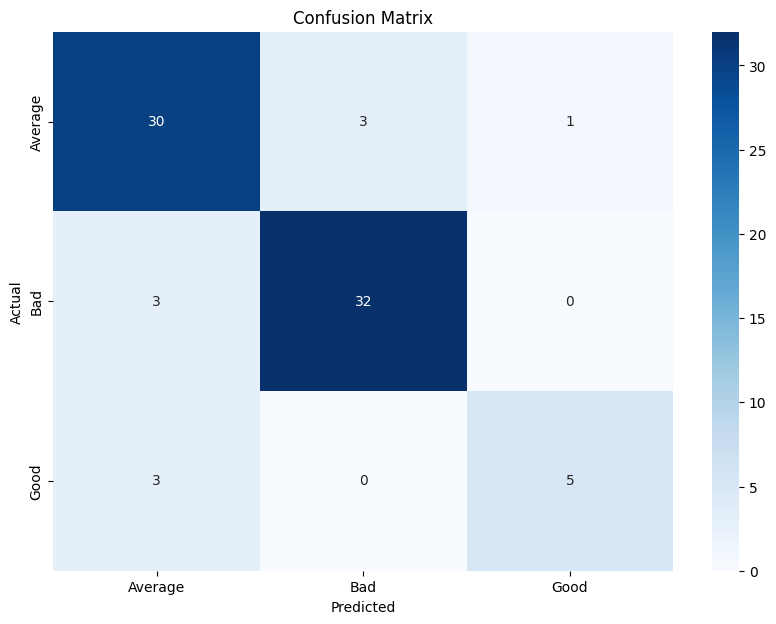

In [20]:
# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
# ROC Curve
y_test_binarized = pd.get_dummies(y_test)  # Binarize y_test for multi-class ROC
new_y_test_binarized = y_test_binarized.reindex(columns=rf_model.classes_, fill_value=0)

fpr, tpr, roc_auc = {}, {}, {}
for i, class_label in enumerate(rf_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(new_y_test_binarized.iloc[:, i], y_pred_prob[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])


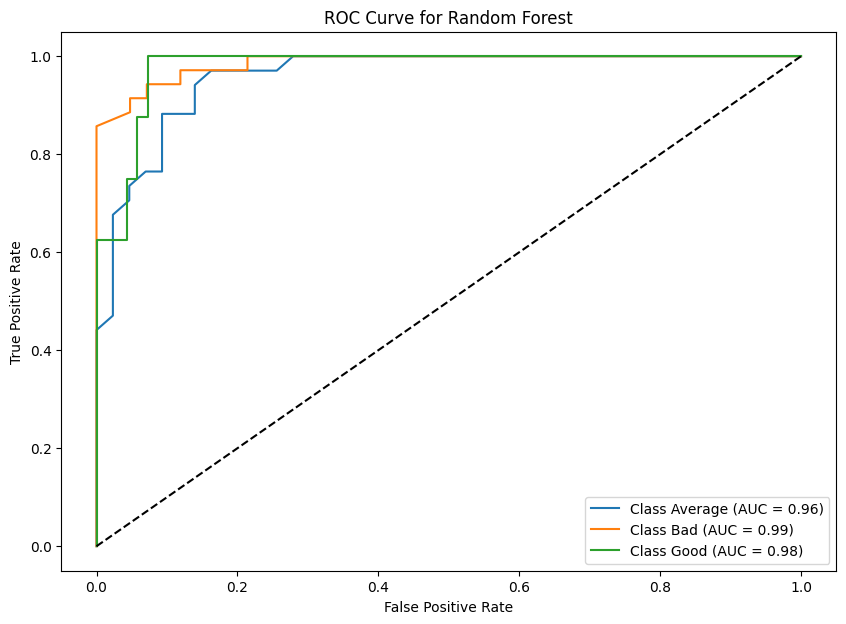

In [22]:
# Plot ROC curves for each class
plt.figure(figsize=(10, 7))
for class_label in rf_model.classes_:
    plt.plot(fpr[class_label], tpr[class_label], label=f"Class {class_label} (AUC = {roc_auc[class_label]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend(loc="lower right")
plt.show()


In [23]:
# Output results
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep)


Accuracy: 0.8701298701298701
Classification Report:
               precision    recall  f1-score   support

     Average       0.83      0.88      0.86        34
         Bad       0.91      0.91      0.91        35
        Good       0.83      0.62      0.71         8

    accuracy                           0.87        77
   macro avg       0.86      0.81      0.83        77
weighted avg       0.87      0.87      0.87        77



In [24]:
print(features_encoded.shape)


(382, 61)


In [26]:
print(student_mat.columns)



Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
